# CheXpert Plus — Exploratory Data Analysis (Report Section Labels)

This notebook performs EDA on **`report.csv`** — the 14 CheXpert observation labels extracted from the **Report** section of the radiology report (Stanford AIMI, CheXpert Plus, via Redivis).

**Label encoding (standard CheXpert convention):**
| Value | Meaning |
|---|---|
| `1.0` | Positive mention |
| `0.0` | Negative mention |
| `-1.0` | Uncertain mention |
| `NaN` / blank | Not mentioned |

**Columns expected:** `path_to_image` + 14 CheXpert observation labels.


## Section 1 — Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

LABEL_COLS = [
    "Enlarged Cardiomediastinum",
    "Cardiomegaly",
    "Lung Opacity",
    "Lung Lesion",
    "Edema",
    "Consolidation",
    "Pneumonia",
    "Atelectasis",
    "Pneumothorax",
    "Pleural Effusion",
    "Pleural Other",
    "Fracture",
    "Support Devices",
    "No Finding",
]
PATHOLOGY_COLS = [c for c in LABEL_COLS if c != "No Finding"]


## Section 2 — Load Data

Update `DATA_PATH` to point to your local `report.csv`.

In [2]:
DATA_PATH = "report.csv"  # <-- update if needed

df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()


Rows: 223,462 | Columns: 15


,path_to_image,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
0,train/patient42142/study5/view1_frontal.jpg,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,1.0,NaN
1,train/patient42142/study8/view1_frontal.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,NaN,NaN,NaN,1.0,NaN
2,train/patient42142/study2/view1_frontal.jpg,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN
3,train/patient42142/study4/view1_frontal.jpg,NaN,0.0,NaN,NaN,NaN,-1.0,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN
4,train/patient42142/study3/view1_frontal.jpg,NaN,NaN,NaN,NaN,0.0,0.0,NaN,1.0,NaN,0.0,NaN,NaN,1.0,NaN


In [3]:
missing_expected = [c for c in LABEL_COLS if c not in df.columns]
if missing_expected:
    print("WARNING - expected columns not found:", missing_expected)
else:
    print("All 14 expected CheXpert label columns present.")


All 14 expected CheXpert label columns present.


## Section 3 — Basic Structure & Data Types

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 223462 entries, 0 to 223461
Data columns (total 15 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   path_to_image               223462 non-null  str    
 1   Enlarged Cardiomediastinum  61189 non-null   float64
 2   Cardiomegaly                69191 non-null   float64
 3   Lung Opacity                117615 non-null  float64
 4   Lung Lesion                 15983 non-null   float64
 5   Edema                       90358 non-null   float64
 6   Consolidation               76072 non-null   float64
 7   Pneumonia                   33728 non-null   float64
 8   Atelectasis                 74295 non-null   float64
 9   Pneumothorax                89232 non-null   float64
 10  Pleural Effusion            145504 non-null  float64
 11  Pleural Other               8781 non-null    float64
 12  Fracture                    16287 non-null   float64
 13  Support Devices          

In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
path_to_image,223462,223462,train/patient42142/study5/view1_frontal.jpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Enlarged Cardiomediastinum,61189.0,NaN,NaN,NaN,-0.166468,0.66147,-1.0,-1.0,0.0,0.0,1.0
Cardiomegaly,69191.0,NaN,NaN,NaN,0.421283,0.668441,-1.0,0.0,1.0,1.0,1.0
Lung Opacity,117615.0,NaN,NaN,NaN,0.93551,0.263978,-1.0,1.0,1.0,1.0,1.0
Lung Lesion,15983.0,NaN,NaN,NaN,0.737534,0.603247,-1.0,1.0,1.0,1.0,1.0
Edema,90358.0,NaN,NaN,NaN,0.456219,0.73249,-1.0,0.0,1.0,1.0,1.0
Consolidation,76072.0,NaN,NaN,NaN,-0.176044,0.729227,-1.0,-1.0,0.0,0.0,1.0
Pneumonia,33728.0,NaN,NaN,NaN,-0.506463,0.776897,-1.0,-1.0,-1.0,0.0,1.0
Atelectasis,74295.0,NaN,NaN,NaN,0.040595,0.994152,-1.0,-1.0,1.0,1.0,1.0
Pneumothorax,89232.0,NaN,NaN,NaN,0.182199,0.462073,-1.0,0.0,0.0,0.0,1.0


In [6]:
n_dupe_rows = df.duplicated().sum()
n_dupe_paths = df["path_to_image"].duplicated().sum()
print(f"Fully duplicated rows: {n_dupe_rows}")
print(f"Duplicated image paths: {n_dupe_paths}")


Fully duplicated rows: 0
Duplicated image paths: 0


## Section 4 — Parsing `path_to_image`

Extracts `split`, `patient_id`, `study_id`, `view_id`, `view_position` from the CheXpert path convention:
`<split>/patient<ID>/study<N>/view<K>_<frontal|lateral>.jpg`


In [7]:
pattern = re.compile(
    r"(?P<split>[^/]+)/patient(?P<patient_id>\d+)/study(?P<study_id>\d+)/"
    r"view(?P<view_id>\d+)_(?P<view_position>\w+)"
)

extracted = df["path_to_image"].astype(str).str.extract(pattern)
df = pd.concat([df, extracted], axis=1)

n_unparsed = df["patient_id"].isna().sum()
print(f"Rows that failed to parse: {n_unparsed} / {len(df)}")
df[["path_to_image", "split", "patient_id", "study_id", "view_id", "view_position"]].head()


Rows that failed to parse: 0 / 223462


,path_to_image,split,patient_id,study_id,view_id,view_position
0,train/patient42142/study5/view1_frontal.jpg,train,42142,5,1,frontal
1,train/patient42142/study8/view1_frontal.jpg,train,42142,8,1,frontal
2,train/patient42142/study2/view1_frontal.jpg,train,42142,2,1,frontal
3,train/patient42142/study4/view1_frontal.jpg,train,42142,4,1,frontal
4,train/patient42142/study3/view1_frontal.jpg,train,42142,3,1,frontal


In [8]:
n_patients = df["patient_id"].nunique()
n_studies = df.dropna(subset=["patient_id", "study_id"]).groupby(["patient_id", "study_id"]).ngroups
n_views = len(df)

print(f"Unique patients : {n_patients:,}")
print(f"Unique studies  : {n_studies:,}")
print(f"Total views/rows: {n_views:,}")
print(f"Avg views/study : {n_views / n_studies:.2f}")


Unique patients : 64,725
Unique studies  : 187,711
Total views/rows: 223,462
Avg views/study : 1.19


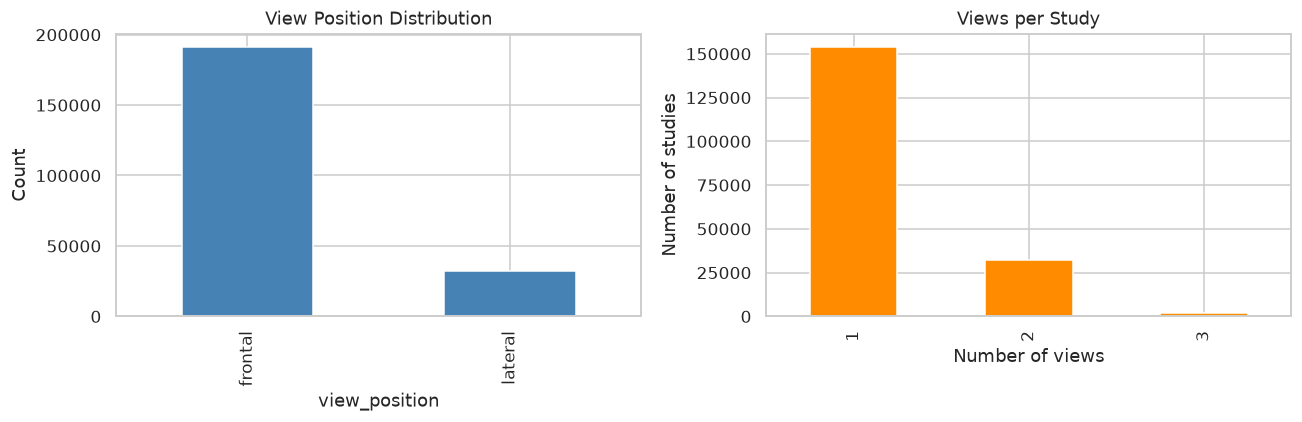

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["view_position"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("View Position Distribution")
axes[0].set_ylabel("Count")

views_per_study = df.dropna(subset=["patient_id", "study_id"]).groupby(["patient_id", "study_id"]).size()
views_per_study.value_counts().sort_index().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Views per Study")
axes[1].set_xlabel("Number of views")
axes[1].set_ylabel("Number of studies")

plt.tight_layout()
plt.show()


## Section 5 — Missingness Across Label Columns

In the Report section, a blank/NaN cell means the observation was **not mentioned in that section specifically** — this can differ from Findings/Report sections, since summaries and full text mention findings at different rates.


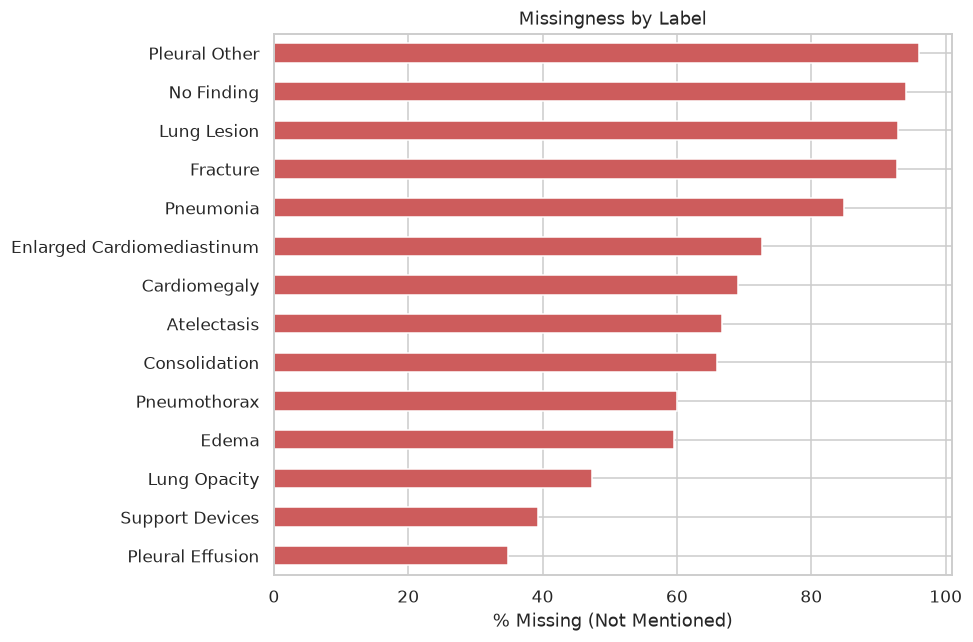

,pct_missing
Pleural Other,96.070473
No Finding,94.158738
Lung Lesion,92.847553
Fracture,92.711512
Pneumonia,84.906606
Enlarged Cardiomediastinum,72.617716
Cardiomegaly,69.036794
Atelectasis,66.752736
Consolidation,65.957523
Pneumothorax,60.068379


In [10]:
missing_pct = df[LABEL_COLS].isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 6))
missing_pct.plot(kind="barh", color="indianred")
plt.xlabel("% Missing (Not Mentioned)")
plt.title("Missingness by Label")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

missing_pct.to_frame("pct_missing")


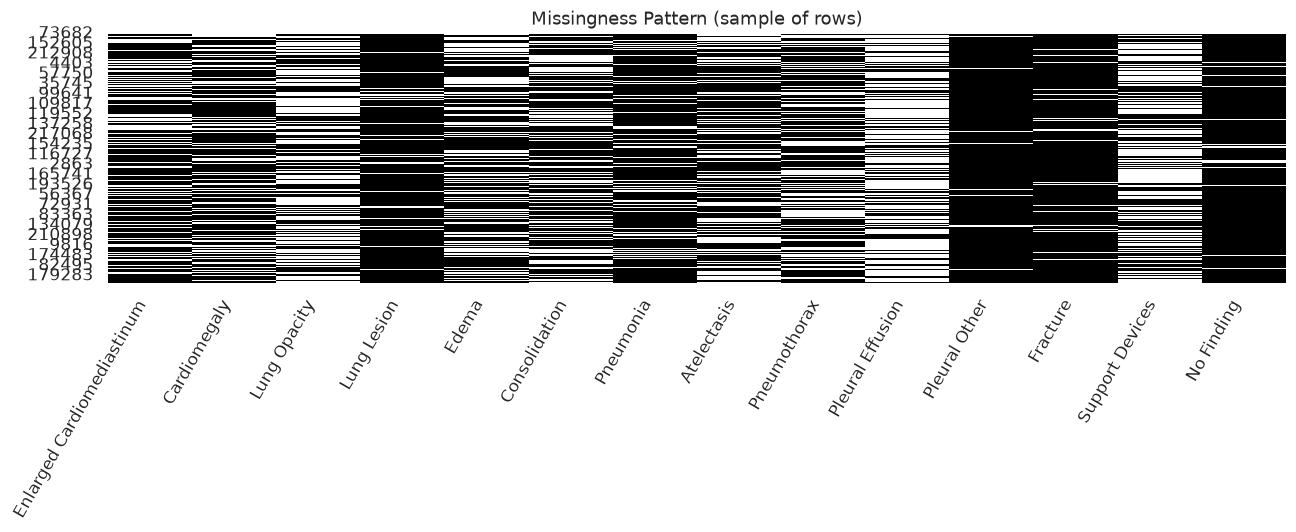

In [11]:
plt.figure(figsize=(12, 5))
sample = df[LABEL_COLS].sample(min(2000, len(df)), random_state=42)
sns.heatmap(sample.isna(), cbar=False, cmap="Greys")
plt.title("Missingness Pattern (sample of rows)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


## Section 6 — Label Value Distribution (Positive / Negative / Uncertain / Not Mentioned)

In [12]:
def label_breakdown(df, cols):
    rows = []
    for c in cols:
        vc = df[c].value_counts(dropna=False)
        rows.append({
            "label": c,
            "positive (1.0)": vc.get(1.0, 0),
            "negative (0.0)": vc.get(0.0, 0),
            "uncertain (-1.0)": vc.get(-1.0, 0),
            "not_mentioned (NaN)": df[c].isna().sum(),
        })
    out = pd.DataFrame(rows).set_index("label")
    out["total"] = out.sum(axis=1)
    return out

breakdown = label_breakdown(df, LABEL_COLS)
breakdown


,positive (1.0),negative (0.0),uncertain (-1.0),not_mentioned (NaN),total
label,,,,,
Enlarged Cardiomediastinum,9141,32721,19327,162273,223462
Cardiomegaly,36172,25996,7023,154271,223462
Lung Opacity,110580,6485,550,105847,223462
Lung Lesion,13149,1473,1361,207479,223462
Edema,54255,23071,13032,133104,223462
Consolidation,14709,33262,28101,147390,223462
Pneumonia,5963,4720,23045,189734,223462
Atelectasis,38283,745,35267,149167,223462
Pneumothorax,19136,67218,2878,134230,223462


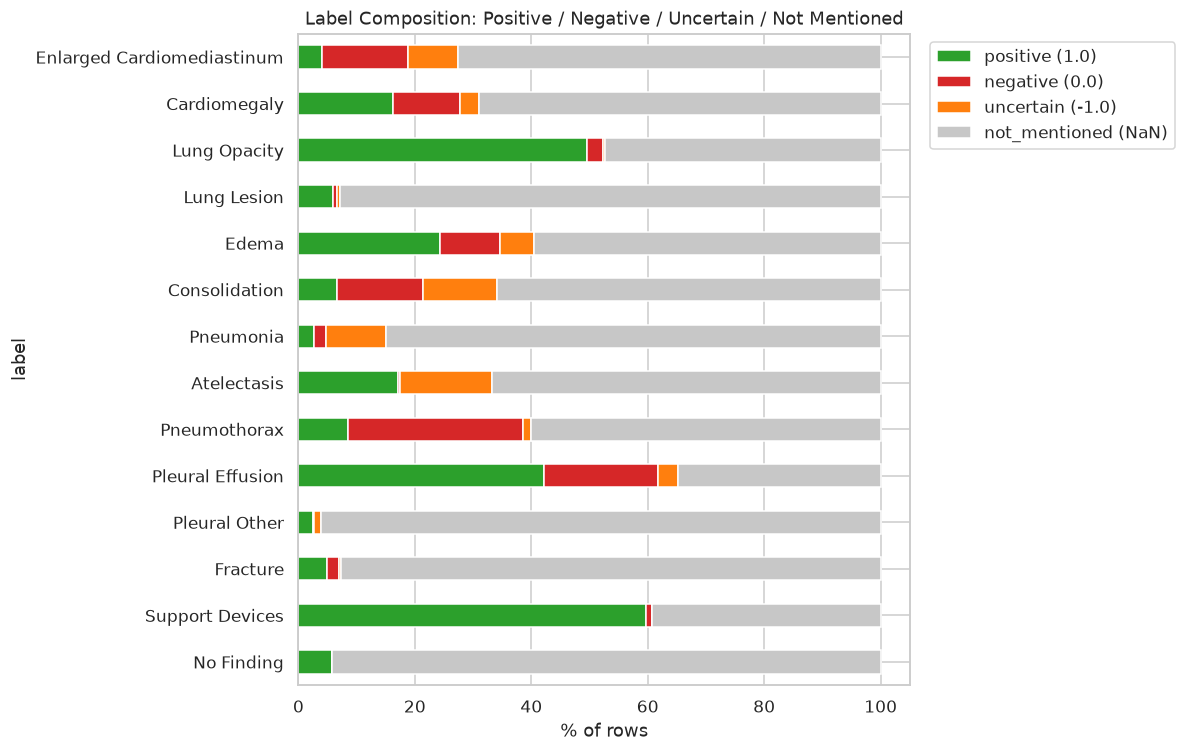

In [13]:
pct_breakdown = breakdown.drop(columns="total").div(breakdown["total"], axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 7))
pct_breakdown.plot(kind="barh", stacked=True, ax=ax,
                    color=["#2ca02c", "#d62728", "#ff7f0e", "#c7c7c7"])
ax.set_xlabel("% of rows")
ax.set_title("Label Composition: Positive / Negative / Uncertain / Not Mentioned")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


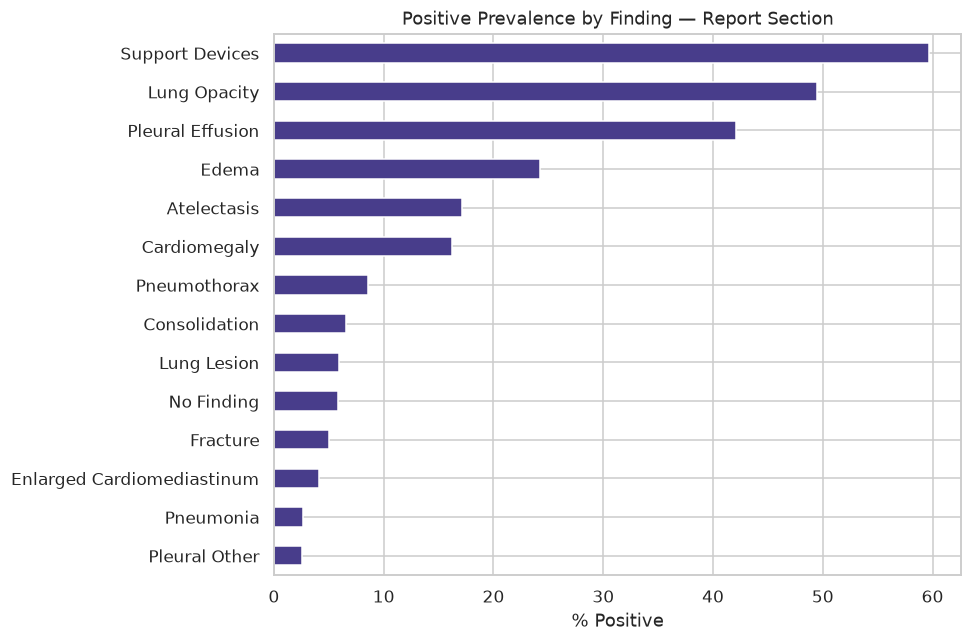

,pct_positive
Support Devices,59.644145
Lung Opacity,49.484924
Pleural Effusion,42.099328
Edema,24.279296
Atelectasis,17.131772
Cardiomegaly,16.187092
Pneumothorax,8.563425
Consolidation,6.582327
Lung Lesion,5.884222
No Finding,5.841262


In [14]:
pos_rate = (df[LABEL_COLS] == 1.0).mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 6))
pos_rate.plot(kind="barh", color="darkslateblue")
plt.xlabel("% Positive")
plt.title("Positive Prevalence by Finding — Report Section")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

pos_rate.to_frame("pct_positive")


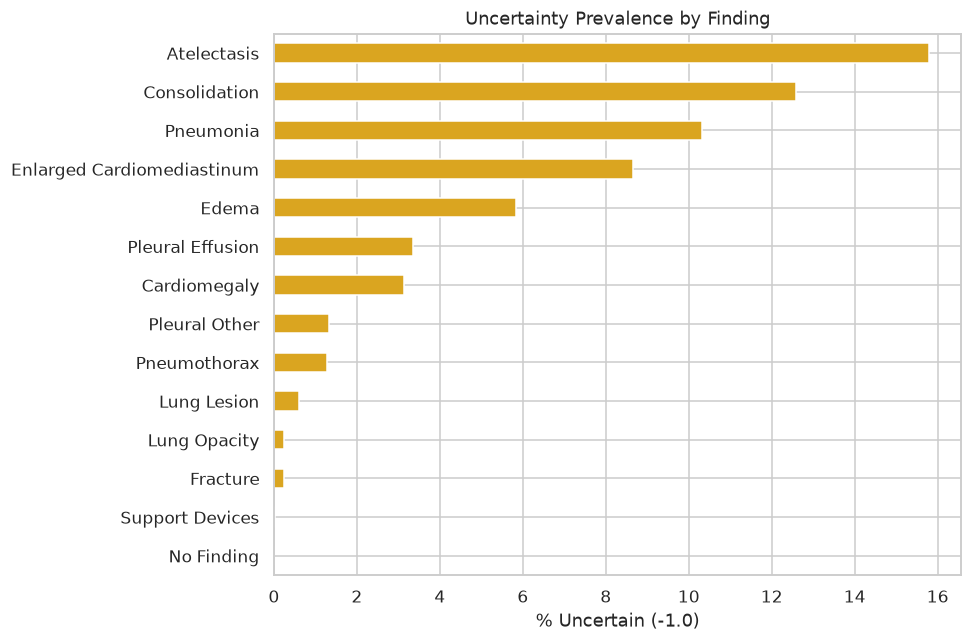

In [15]:
uncertain_rate = (df[LABEL_COLS] == -1.0).mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 6))
uncertain_rate.plot(kind="barh", color="goldenrod")
plt.xlabel("% Uncertain (-1.0)")
plt.title("Uncertainty Prevalence by Finding")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Section 7 — `No Finding` Sanity Checks

Flags rows where `No Finding == 1` but a pathology label is also positive (should be rare/zero if labeling is internally consistent).


In [16]:
no_finding_rows = df[df["No Finding"] == 1.0]
violations = no_finding_rows[(no_finding_rows[PATHOLOGY_COLS] == 1.0).any(axis=1)]

print(f"Rows with No Finding == 1 : {len(no_finding_rows):,}")
print(f"Of these, rows with a co-occurring positive pathology label (should be ~0): {len(violations):,}")

if len(violations):
    display_cols = ["path_to_image"] + PATHOLOGY_COLS
    violations[display_cols].head(10)


Rows with No Finding == 1 : 13,053
Of these, rows with a co-occurring positive pathology label (should be ~0): 6,042


## Section 8 — Multi-Label Characteristics

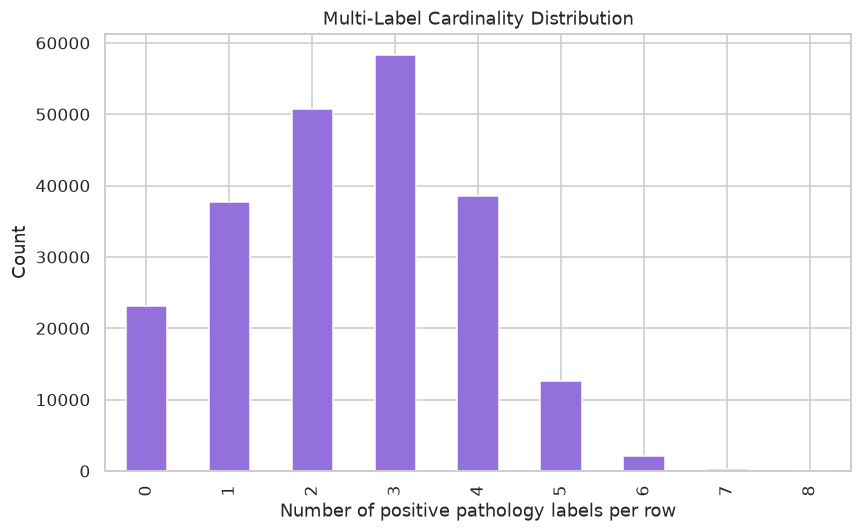

count    223462.000000
mean          2.441798
std           1.423264
min           0.000000
25%           1.000000
50%           3.000000
75%           3.000000
max           8.000000
Name: n_positive_labels, dtype: float64


In [17]:
df["n_positive_labels"] = (df[PATHOLOGY_COLS] == 1.0).sum(axis=1)

plt.figure(figsize=(8, 5))
df["n_positive_labels"].value_counts().sort_index().plot(kind="bar", color="mediumpurple")
plt.xlabel("Number of positive pathology labels per row")
plt.ylabel("Count")
plt.title("Multi-Label Cardinality Distribution")
plt.tight_layout()
plt.show()

print(df["n_positive_labels"].describe())


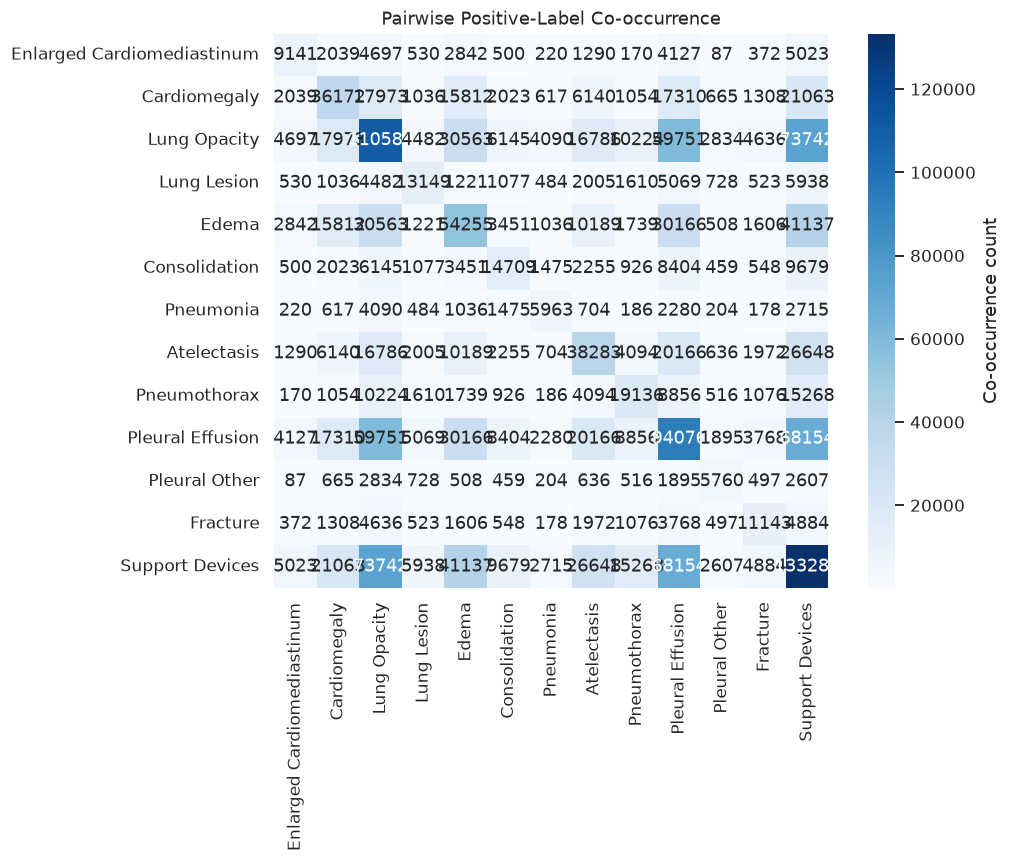

In [18]:
pos_matrix = (df[PATHOLOGY_COLS] == 1.0).astype(int)
cooc = pos_matrix.T.dot(pos_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(cooc, annot=True, fmt="d", cmap="Blues", square=True, cbar_kws={"label": "Co-occurrence count"})
plt.title("Pairwise Positive-Label Co-occurrence")
plt.tight_layout()
plt.show()


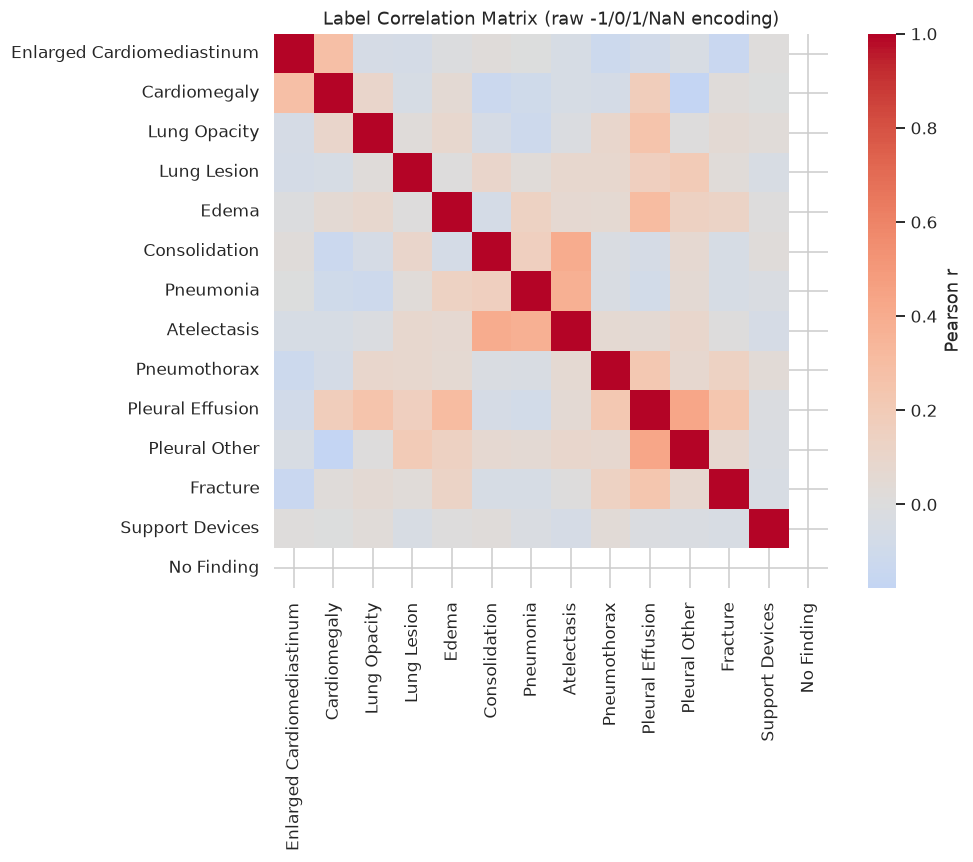

In [19]:
corr = df[LABEL_COLS].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, square=True, cbar_kws={"label": "Pearson r"})
plt.title("Label Correlation Matrix (raw -1/0/1/NaN encoding)")
plt.tight_layout()
plt.show()


## Section 9 — Patient-Level Summary

In [20]:
patient_pos = df.groupby("patient_id")[PATHOLOGY_COLS].max()
patient_pos["n_distinct_positive_findings"] = (patient_pos == 1.0).sum(axis=1)

top_complex_patients = patient_pos.sort_values("n_distinct_positive_findings", ascending=False).head(10)
top_complex_patients[["n_distinct_positive_findings"]]


,n_distinct_positive_findings
patient_id,
08549,13
30494,13
07632,13
23236,13
15482,13
21622,13
09793,13
06028,13
21088,13


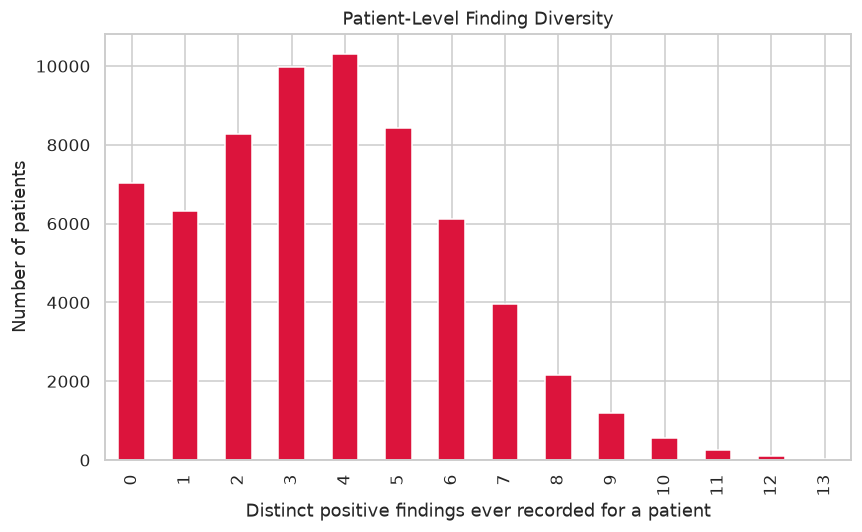

In [21]:
plt.figure(figsize=(8, 5))
patient_pos["n_distinct_positive_findings"].value_counts().sort_index().plot(kind="bar", color="crimson")
plt.xlabel("Distinct positive findings ever recorded for a patient")
plt.ylabel("Number of patients")
plt.title("Patient-Level Finding Diversity")
plt.tight_layout()
plt.show()


## Section 10 — Report Text Length (optional — only if raw text column present)

Skips gracefully if `report.csv` is labels-only (no free-text column).


In [22]:
candidate_cols = ("report", "report_text", "text")
text_col = next((c for c in candidate_cols if c in df.columns and df[c].dtype == object and c != "path_to_image"), None)

if text_col is None:
    print("No raw text column detected — this file appears to be labels-only. Skipping length analysis.")
else:
    lengths = df[text_col].astype(str).str.split().str.len()
    print(lengths.describe())
    plt.figure(figsize=(7, 4))
    lengths.plot(kind="hist", bins=40, color="slateblue", alpha=0.8)
    plt.xlabel("Word count")
    plt.title("Report Length Distribution")
    plt.tight_layout()
    plt.show()


No raw text column detected — this file appears to be labels-only. Skipping length analysis.


## Section 11 — Class Imbalance Summary (for modeling)

In [23]:
imbalance = pd.DataFrame({
    "positive_rate_%": pos_rate,
    "negative_rate_%": (df[LABEL_COLS] == 0.0).mean() * 100,
    "uncertain_rate_%": uncertain_rate,
    "missing_rate_%": missing_pct,
})
imbalance["pos_neg_ratio"] = imbalance["positive_rate_%"] / imbalance["negative_rate_%"].replace(0, np.nan)
imbalance.sort_values("positive_rate_%", ascending=False).round(2)


,positive_rate_%,negative_rate_%,uncertain_rate_%,missing_rate_%,pos_neg_ratio
Support Devices,59.64,1.02,0.02,39.32,58.48
Lung Opacity,49.48,2.90,0.25,47.37,17.05
Pleural Effusion,42.10,19.67,3.34,34.89,2.14
Edema,24.28,10.32,5.83,59.56,2.35
Atelectasis,17.13,0.33,15.78,66.75,51.39
Cardiomegaly,16.19,11.63,3.14,69.04,1.39
Pneumothorax,8.56,30.08,1.29,60.07,0.28
Consolidation,6.58,14.88,12.58,65.96,0.44
Lung Lesion,5.88,0.66,0.61,92.85,8.93
No Finding,5.84,0.00,0.00,94.16,NaN


## Section 12 — Export Summary Artifacts

In [24]:
out_dir = Path("eda_outputs")
out_dir.mkdir(exist_ok=True)

breakdown.to_csv(out_dir / "report_label_breakdown.csv")
imbalance.to_csv(out_dir / "report_class_imbalance_summary.csv")
cooc.to_csv(out_dir / "report_label_cooccurrence_matrix.csv")

print("Saved summary artifacts to:", out_dir.resolve())


Saved summary artifacts to: /home/yash/Documents/Major/eda_outputs


## Section 13 — Key Takeaways (fill in after running)

- Dataset size: **studies / patients / images** — see Section 4 output.
- Most prevalent positive finding in the Report section: *fill in from Section 6*.
- Most uncertain finding: *fill in from Section 6*.
- `No Finding` consistency check result: *fill in from Section 7*.
- Average positive labels per study: *fill in from Section 8*.
- Strongest co-occurring pairs: *fill in from Section 8 heatmap*.

> Compare these numbers against the `findings.csv` and cross-section notebooks to see how the Report section's labeling behavior differs (e.g. the Impression section typically has higher missingness for incidental findings than the full Report).
